
# Module 24: Principal Component Analysis (PCA)

This notebook is a **practice-only notebook** for students.

### Instructions for Students
- Complete every **TODO** step by step.
- Run the cells after completing each TODO.
- Focus on *why* you are doing each step, not just *how*.

### Dataset Used
We use the **Breast Cancer Wisconsin dataset**, which is:
- Numeric
- Medium dimensional (30 features)
- Very suitable for PCA
- Common in real ML pipelines



## 1) Imports (Given)


In [26]:
#Given for you
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report


## 2) Load the Dataset (TODO)

TODO:
- Load the breast cancer dataset using sklearn
- Create:
  - X: feature DataFrame
  - y: target Series
- Print the shape of X and y


In [3]:
# TODO: Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
print(X.shape)
print(y.shape)

(569, 30)
(569,)



## 3) Inspect Feature Scales (TODO)


In [4]:
# TODO: Inspect feature statistics
X.describe().T



,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



## 4) Scale the Features (TODO)


In [6]:
# TODO: Scale features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 5) Fit PCA Without Limiting Components (TODO)


In [16]:
# TODO: Fit full PCA and compute explained variance
pca = PCA()

x_pca_full = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

cumulative_explained_variance=np.cumsum(explained_variance)

print(explained_variance[:10])


[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]


In [15]:
print(cumulative_explained_variance[:10])

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881]



## 6) Explained Variance Plot (TODO)


/tmp/ipython-input-3332507090.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


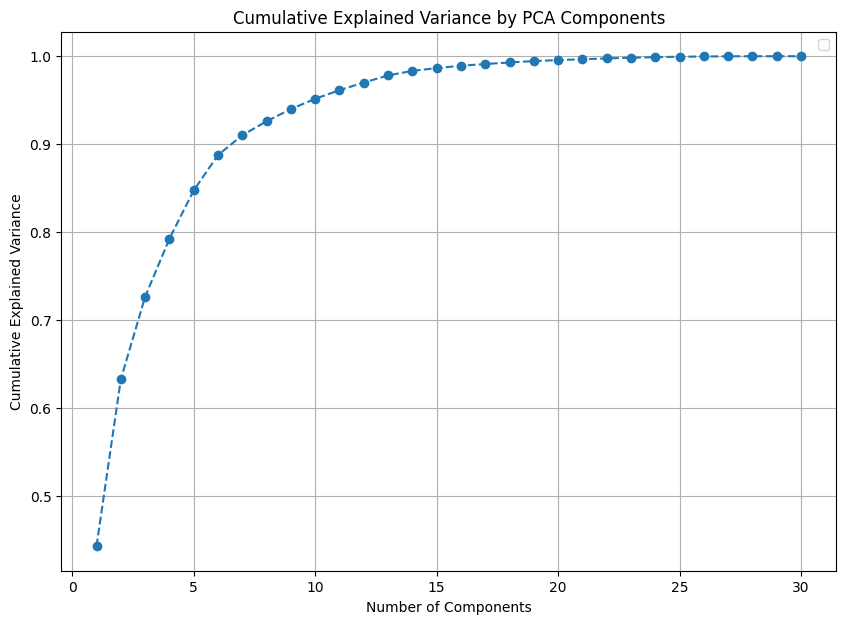

In [17]:
cumulative_explained_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 7))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)



plt.legend()
plt.show()


## 7) Choose Number of Components (TODO)


In [19]:
# TODO: Find k90 and k95 and k97
def components_for_threshold(cumulative_explained_variance, threshold):
    return np.argmax(cumulative_explained_variance >= threshold) + 1

k90 = components_for_threshold(cumulative_explained_variance, 0.9)
print(k90)
k95 = components_for_threshold(cumulative_explained_variance, 0.95)
print(k95)
k97 = components_for_threshold(cumulative_explained_variance, 0.97)
print(k97)

7
10
12



## 8) Apply PCA with Chosen Components (TODO)


In [20]:
# TODO: Apply PCA with selected number of components

pca_90 = PCA(n_components=k90)
pca_95 = PCA(n_components=k95)
pca_97 = PCA(n_components=k97)




## 9) Inspect Principal Components (TODO)


In [21]:
# TODO: Inspect PCA loadings
pca_90.fit(X_scaled)
pca_95.fit(X_scaled)
pca_97.fit(X_scaled)

print(pca_90.components_)
print(pca_95.components_)
print(pca_97.components_)

[[ 2.18902444e-01  1.03724578e-01  2.27537293e-01  2.20994985e-01
   1.42589694e-01  2.39285354e-01  2.58400481e-01  2.60853758e-01
   1.38166959e-01  6.43633464e-02  2.05978776e-01  1.74280281e-02
   2.11325916e-01  2.02869635e-01  1.45314521e-02  1.70393451e-01
   1.53589790e-01  1.83417397e-01  4.24984216e-02  1.02568322e-01
   2.27996634e-01  1.04469325e-01  2.36639681e-01  2.24870533e-01
   1.27952561e-01  2.10095880e-01  2.28767533e-01  2.50885971e-01
   1.22904556e-01  1.31783943e-01]
 [-2.33857132e-01 -5.97060883e-02 -2.15181361e-01 -2.31076711e-01
   1.86113023e-01  1.51891610e-01  6.01653628e-02 -3.47675005e-02
   1.90348770e-01  3.66575471e-01 -1.05552152e-01  8.99796818e-02
  -8.94572342e-02 -1.52292628e-01  2.04430453e-01  2.32715896e-01
   1.97207283e-01  1.30321560e-01  1.83848000e-01  2.80092027e-01
  -2.19866379e-01 -4.54672983e-02 -1.99878428e-01 -2.19351858e-01
   1.72304352e-01  1.43593173e-01  9.79641143e-02 -8.25723507e-03
   1.41883349e-01  2.75339469e-01]
 [-8.5


## 10) Visualize Data Using First Two Principal Components (TODO)


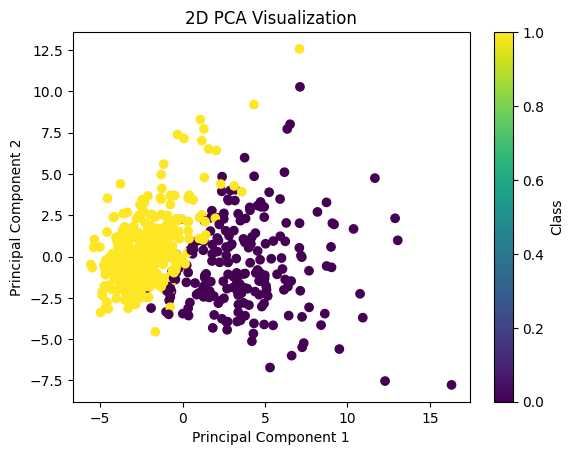

In [22]:
# TODO: 2D PCA visualization

pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(x_pca_2d[:, 0], x_pca_2d[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid
plt.title('2D PCA Visualization')
plt.colorbar(label='Class')
plt.show()



## 11) PCA in a Model Pipeline (TODO)


In [23]:
# TODO: Model comparison with and without PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Pipeline without PCA

pipeline_without_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

pipeline_without_pca.fit(X_train, y_train)
y_pred_without_pca = pipeline_without_pca.predict(X_test)
accuracy_without_pca = accuracy_score(y_test, y_pred_without_pca)
print(f"Accuracy without PCA: {accuracy_without_pca}")



Accuracy without PCA: 0.9736842105263158


In [27]:
print(classification_report(y_test, y_pred_without_pca))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [29]:
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('classifier', LogisticRegression())
])

pipeline_with_pca.fit(X_train, y_train)
y_pred_with_pca = pipeline_with_pca.predict(X_test)
accuracy_with_pca = accuracy_score(y_test, y_pred_with_pca)

print(f"Accuracy with PCA: {accuracy_with_pca}")

Accuracy with PCA: 0.9824561403508771


In [30]:
print(classification_report(y_test, y_pred_with_pca))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114




## 12) Reflection Questions

Answer briefly in markdown:
1. Did PCA reduce the number of features significantly?
2. Did PCA improve, reduce, or maintain accuracy?
3. Would you use PCA for this dataset in a real project? Why or why not?
